In [26]:
import pandas
from datetime import datetime
from pytz import utc
import matplotlib.pyplot as plt

data = pandas.read_csv('../Seccion_20/data/reviews.csv')
data.head()

,Course Name,Timestamp,Rating,Comment
0,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 06:25:52+00:00,4.0,NaN
1,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 05:12:34+00:00,4.0,NaN
2,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 05:11:03+00:00,4.0,NaN
3,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 03:33:24+00:00,5.0,NaN
4,The Python Mega Course: Build 10 Real World Ap...,2021-04-02 03:31:49+00:00,4.5,NaN


,Course Name,Timestamp,Rating,Comment
Day,,,,
2018-01-01,46,46,46,7
2018-01-02,57,57,57,16
2018-01-03,43,43,43,8
2018-01-04,48,48,48,11
2018-01-05,52,52,52,15


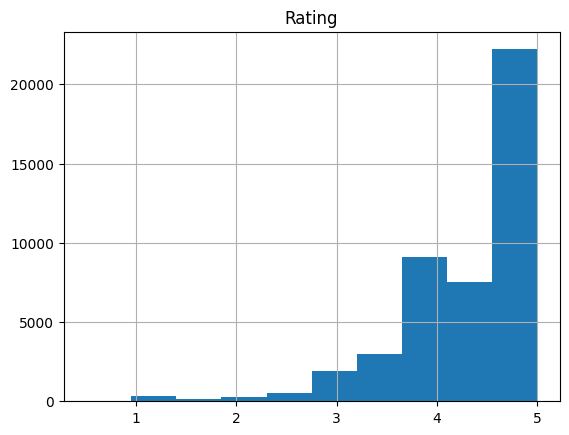

In [27]:
data.hist('Rating') # Create a histogram of the 'Rating' column

# Convert Timestamp column to datetime format first
data['Timestamp'] = pandas.to_datetime(data['Timestamp'])

data['Day'] = data['Timestamp'].dt.date # Extract date from 'Timestamp' and create a new 'Day' column
day_average = data.groupby('Day').count() # Group by 'Day' and calculate mean for each day
day_average.head() # Display the first few rows of the daily average ratings

### 1. Selecting data from the DataFrame

In [30]:
# Check available columns in the DataFrame
print("Columnas disponibles:", data.columns.tolist())
print("Forma del DataFrame:", data.shape)
print("\nTipos de datos:")
print(data.dtypes)

Columnas disponibles: ['Course Name', 'Timestamp', 'Rating', 'Comment', 'Day']
Forma del DataFrame: (45000, 5)

Tipos de datos:
Course Name                 object
Timestamp      datetime64[ns, UTC]
Rating                     float64
Comment                     object
Day                         object
dtype: object


In [33]:
# Select a column
data['Rating'] # Access the 'Rating' column from the DataFrame
data['Rating'].mean() # Calculate the mean of the 'Rating' column

# Select multiple columns (using correct column names)
data[['Rating', 'Course Name']] # Access both 'Rating' and 'Course Name' columns

# Select a row
data.iloc[3] # Access the fourth row of the DataFrame

# Select multiple rows
data.iloc[2:5] # Access rows from index 2 to 4

# Select a section of the DataFrame
data[['Rating', 'Course Name']].iloc[2:5] # Access rows 2 to 4 and columns 'Rating' and 'Course Name'

# Select a cell
data['Course Name'].iloc[3] # Access the 'Course Name' of the fourth row
data.at[3, 'Course Name'] # Another way to access the 'Course Name' of the fourth row
data.iat[3, 0] # Access the cell at row index 3 and column index 0 (Course Name)

# Additional examples with other available columns
data[['Rating', 'Comment']].head() # Access 'Rating' and 'Comment' columns
data['Comment'].iloc[3] # Access the 'Comment' of the fourth row

# Exploring missing values in Comments
print("Total de reseñas:", len(data))
print("Reseñas con comentarios:", data['Comment'].notna().sum()) 
print("Reseñas sin comentarios (NaN):", data['Comment'].isna().sum())
print("Porcentaje con comentarios: {:.1f}%".format(data['Comment'].notna().sum() / len(data) * 100))

# Show some examples of rows with comments
print("\nEjemplos de reseñas con comentarios:")
data[data['Comment'].notna()][['Course Name', 'Rating', 'Comment']].head(3)

Total de reseñas: 45000
Reseñas con comentarios: 6799
Reseñas sin comentarios (NaN): 38201
Porcentaje con comentarios: 15.1%

Ejemplos de reseñas con comentarios:


,Course Name,Rating,Comment
11,The Python Mega Course: Build 10 Real World Ap...,5.0,No
19,100 Python Exercises I: Evaluate and Improve Y...,4.5,Excellent set of practical problems. Thank you!
22,The Python Mega Course: Build 10 Real World Ap...,5.0,Great course.


### 2. Filtering data based on conditions

In [35]:
# One condition
data[data['Rating'] > 4] # Select rows where 'Rating' is greater than 4
data[data['Rating'] == 4] # Select rows where 'Rating' is equal to 4
data[data['Rating'] < 4] # Select rows where 'Rating' is less than 4

# Multiple conditions
data[(data['Rating'] > 4) & (data['Course Name'] == 'The Python Mega Course: Build 10 Real World Applications')] # 'Rating' greater than 4 and 'Course Name' is 'The Python Mega Course'
data[(data['Rating'] < 2) | (data['Course Name'] == 'Interactive Data Visualization with Python and Bokeh')] # 'Rating' less than 2 or 'Course Name' is 'Interactive Data Visualization'
data[data['Course Name'].isin(['The Python Mega Course: Build 10 Real World Applications', 'The Complete Python Course: Build 10 Professional OOP Apps'])] # 'Course Name' is either 'Python Mega Course' or 'Complete Python Course'
data[~data['Course Name'].isin(['The Python Mega Course: Build 10 Real World Applications', '100 Python Exercises I: Evaluate and Improve Your Skills'])] # 'Course Name' is neither 'Python Mega Course' nor 'Python Exercises'

# Time-based filtering (fixed timezone issues)
data[data['Timestamp'] >= datetime(2020, 1, 1, tzinfo=utc)] # Select rows where 'Timestamp' is on or after January 1, 2020
data[data['Timestamp'] < datetime(2020, 1, 1, tzinfo=utc)] # Select rows where 'Timestamp' is before January 1, 2020
data[(data['Timestamp'] >= datetime(2020, 1, 1, tzinfo=utc)) & (data['Timestamp'] <= datetime(2020, 12, 31, tzinfo=utc))]['Rating'].mean() # Select rows in 2020 and calculate mean 'Rating'
data[(data['Timestamp'] >= datetime(2020, 1, 1, tzinfo=utc)) & (data['Timestamp'] <= datetime(2020, 12, 31, tzinfo=utc)) & (data['Course Name'] == 'The Python Mega Course: Build 10 Real World Applications')]['Rating'].mean() # Select rows in 2020 for 'Python Mega Course' and calculate mean 'Rating'

# Additional time filtering examples
data[data['Timestamp'] >= datetime(2021, 1, 1, tzinfo=utc)]['Rating'].count() # Count reviews from 2021 onwards
data[(data['Timestamp'] >= datetime(2018, 1, 1, tzinfo=utc)) & (data['Timestamp'] < datetime(2019, 1, 1, tzinfo=utc))].shape[0] # Count reviews in 2018

# Filtering with string methods
data[data['Course Name'].str.contains('Python Mega Course', na=False)] # 'Course Name' contains 'Python Mega Course'
data[~data['Course Name'].str.contains('Python Mega Course', na=False)] # 'Course Name' does not contain 'Python Mega Course'
data[data['Course Name'].str.startswith('The Python', na=False)] # 'Course Name' starts with 'The Python'
data[data['Course Name'].str.endswith('Applications', na=False)] # 'Course Name' ends with 'Applications'
data[data['Comment'].str.contains('accent', na=False, case=False)]['Rating'].count() # Count of 'Comment' containing 'accent' (case-insensitive)
data[data['Course Name'].str.len() > 50] # 'Course Name' length greater than 50
data[data['Course Name'].str.len() < 30] # 'Course Name' length less than 30
data[data['Course Name'].str.len() == 69] # 'Course Name' length equal to 69

# Conditional assignment (commented out to preserve original data)
# data.loc[data['Rating'] > 4, 'Comment'] = 'Excellent rating' # Set 'Comment' to 'Excellent rating' where 'Rating' is greater than 4
# data.loc[data['Rating'] < 2, 'Comment'] = 'Poor rating' # Set 'Comment' to 'Poor rating' where 'Rating' is less than 2
# data.loc[data['Course Name'].str.contains('Python Mega Course', na=False), 'Comment'] = 'Mega Course review' # Set 'Comment' where 'Course Name' contains 'Python Mega Course'

print("Filtrado completado exitosamente")

Filtrado completado exitosamente


In [36]:
# === EJEMPLOS PRÁCTICOS DE FILTRADO CON RESULTADOS VISIBLES ===

print("=== 1. FILTRADO POR CALIFICACIÓN ===")
print(f"Reseñas con rating > 4: {len(data[data['Rating'] > 4]):,}")
print(f"Reseñas con rating = 4: {len(data[data['Rating'] == 4]):,}")
print(f"Reseñas con rating < 4: {len(data[data['Rating'] < 4]):,}")

print("\n=== 2. FILTRADO POR CURSO ESPECÍFICO ===")
mega_course = data[data['Course Name'] == 'The Python Mega Course: Build 10 Real World Applications']
print(f"Total de reseñas del Python Mega Course: {len(mega_course):,}")
print(f"Rating promedio del Mega Course: {mega_course['Rating'].mean():.2f}")

print("\n=== 3. FILTRADO TEMPORAL ===")
reviews_2020 = data[(data['Timestamp'] >= datetime(2020, 1, 1, tzinfo=utc)) & (data['Timestamp'] <= datetime(2020, 12, 31, tzinfo=utc))]
reviews_2021 = data[data['Timestamp'] >= datetime(2021, 1, 1, tzinfo=utc)]
reviews_2018 = data[(data['Timestamp'] >= datetime(2018, 1, 1, tzinfo=utc)) & (data['Timestamp'] < datetime(2019, 1, 1, tzinfo=utc))]

print(f"Reseñas en 2020: {len(reviews_2020):,} (Rating promedio: {reviews_2020['Rating'].mean():.2f})")
print(f"Reseñas desde 2021: {len(reviews_2021):,}")
print(f"Reseñas en 2018: {len(reviews_2018):,}")

print("\n=== 4. FILTRADO POR TEXTO ===")
python_mega = data[data['Course Name'].str.contains('Python Mega Course', na=False)]
starts_python = data[data['Course Name'].str.startswith('The Python', na=False)]
ends_applications = data[data['Course Name'].str.endswith('Applications', na=False)]

print(f"Cursos que contienen 'Python Mega Course': {len(python_mega):,}")
print(f"Cursos que empiezan con 'The Python': {len(starts_python):,}")
print(f"Cursos que terminan en 'Applications': {len(ends_applications):,}")

print("\n=== 5. FILTRADO POR LONGITUD DE TEXTO ===")
long_names = data[data['Course Name'].str.len() > 50]
short_names = data[data['Course Name'].str.len() < 30]
exact_length = data[data['Course Name'].str.len() == 69]

print(f"Cursos con nombres > 50 caracteres: {len(long_names):,}")
print(f"Cursos con nombres < 30 caracteres: {len(short_names):,}")
print(f"Cursos con nombres de 69 caracteres exactos: {len(exact_length):,}")

print("\n=== 6. FILTRADO COMBINADO ===")
high_rated_mega = data[(data['Rating'] > 4) & (data['Course Name'] == 'The Python Mega Course: Build 10 Real World Applications')]
print(f"Reseñas del Mega Course con rating > 4: {len(high_rated_mega):,}")

recent_high_rated = data[(data['Rating'] > 4) & (data['Timestamp'] >= datetime(2021, 1, 1, tzinfo=utc))]
print(f"Reseñas con rating > 4 desde 2021: {len(recent_high_rated):,}")

print("\n=== 7. EJEMPLOS DE DATOS FILTRADOS ===")
print("\nTop 3 reseñas con mejor calificación:")
top_ratings = data[data['Rating'] == 5].head(3)
for i, row in top_ratings.iterrows():
    print(f"- {row['Course Name'][:40]}... | Rating: {row['Rating']} | Fecha: {row['Timestamp'].strftime('%Y-%m-%d')}")

print("\n=== RESUMEN ESTADÍSTICO POR AÑO ===")
for year in [2018, 2019, 2020, 2021]:
    year_data = data[(data['Timestamp'] >= datetime(year, 1, 1, tzinfo=utc)) & (data['Timestamp'] < datetime(year+1, 1, 1, tzinfo=utc))]
    if len(year_data) > 0:
        print(f"{year}: {len(year_data):,} reseñas | Rating promedio: {year_data['Rating'].mean():.2f}")
    else:
        print(f"{year}: Sin datos")

=== 1. FILTRADO POR CALIFICACIÓN ===
Reseñas con rating > 4: 29,758
Reseñas con rating = 4: 9,115
Reseñas con rating < 4: 6,127

=== 2. FILTRADO POR CURSO ESPECÍFICO ===
Total de reseñas del Python Mega Course: 35,702
Rating promedio del Mega Course: 4.48

=== 3. FILTRADO TEMPORAL ===
Reseñas en 2020: 16,561 (Rating promedio: 4.48)
Reseñas desde 2021: 3,041
Reseñas en 2018: 14,077

=== 4. FILTRADO POR TEXTO ===
Cursos que contienen 'Python Mega Course': 35,702
Cursos que empiezan con 'The Python': 35,702
Cursos que terminan en 'Applications': 35,702

=== 5. FILTRADO POR LONGITUD DE TEXTO ===
Cursos con nombres > 50 caracteres: 38,812
Cursos con nombres < 30 caracteres: 1,367
Cursos con nombres de 69 caracteres exactos: 0

=== 6. FILTRADO COMBINADO ===
Reseñas del Mega Course con rating > 4: 24,260
Reseñas con rating > 4 desde 2021: 2,238

=== 7. EJEMPLOS DE DATOS FILTRADOS ===

Top 3 reseñas con mejor calificación:
- The Python Mega Course: Build 10 Real Wo... | Rating: 5.0 | Fecha: 20

### 3. From data to information

In [37]:
# Handling missing data
data['Comment'].isnull() # Check for missing values in 'Comment' column
data[data['Comment'].isnull()] # Select rows where 'Comment' is missing
data['Comment'].notnull() # Check for non-missing values in 'Comment' column
data['Comment'].fillna(0, inplace=True) # Fill missing values in 'Comment' with 0
data['Comment'].dropna(inplace=True) # Drop missing values in 'Comment' column

# Aggregation methods
data['Rating'].mean() # Calculate the mean of 'Rating'
data['Rating'].median() # Calculate the median of 'Rating'
data['Rating'].head() # Get the first few values of 'Rating'
data['Rating'].tail() # Get the last few values of 'Rating'
data['Rating'].max() # Get the maximum value of 'Rating'
data['Rating'].min() # Get the minimum value of 'Rating'
data['Rating'].std() # Calculate the standard deviation of 'Rating'
data['Rating'].count() # Count non-missing values in 'Rating'
data['Rating'].sum() # Calculate the sum of 'Rating'
data['Rating'].var() # Calculate the variance of 'Rating'
data['Rating'].nunique() # Count unique values in 'Rating'
data['Course Name'].unique() # Get unique values in 'Course Name'
data['Course Name'].value_counts() # Count occurrences of each unique value in 'Course Name'
data['Course Name'].mode() # Get the mode of 'Course Name'
data['Rating'].quantile(0.25) # Get the 25th percentile of 'Rating'
data['Rating'].quantile(0.75) # Get the 75th percentile of 'Rating'


# Grouping data
data.groupby('Course Name')['Rating'].mean() # Group by 'Course Name' and calculate mean 'Rating'
data.groupby('Course Name')['Rating'].max() # Group by 'Course Name' and get max 'Rating'
data.groupby('Course Name')['Rating'].min() # Group by 'Course Name' and get min 'Rating'
data.groupby('Course Name')['Rating'].count() # Group by 'Course Name' and count 'Rating' entries

# Grouping with conditional filtering
data[data['Rating'] > 4].groupby('Course Name')['Rating'].mean() # Group by 'Course Name' and calculate mean 'Rating' for ratings greater than 4
data[data['Rating'] < 2].groupby('Course Name')['Rating'].count() # Group by 'Course Name' and count 'Rating' entries for ratings less than 2

# Others methods
data.sort_values('Rating') # Sort DataFrame by 'Rating' in ascending order
data.sort_values('Rating', ascending=False) # Sort DataFrame by 'Rating' in descending order
data.sort_values(['Course Name', 'Rating']) # Sort by 'Course Name' and then by 'Rating'
data.reset_index(drop=True, inplace=True) # Reset index of the DataFrame
data.describe() # Get summary statistics of the DataFrame
data.info() # Get information about the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   Course Name  45000 non-null  object             
 1   Timestamp    45000 non-null  datetime64[ns, UTC]
 2   Rating       45000 non-null  float64            
 3   Comment      45000 non-null  object             
 4   Day          45000 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), object(3)
memory usage: 1.7+ MB
